# Customer Segmentation using K-Means Clustering

This notebook performs customer segmentation on our e-commerce RFM dataset using K-Means clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('../dataset/rfm_analysis.csv')
df.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment
0,C10545,10,10,6238.82,5,5,5,15,Elite Customers
1,C10954,27,10,6161.11,5,5,5,15,Elite Customers
2,C11781,19,7,5635.55,5,5,5,15,Elite Customers
3,C15752,11,8,5011.05,5,5,5,15,Elite Customers
4,C13414,0,9,4947.89,5,5,5,15,Elite Customers


In [3]:
X = df[['recency', 'frequency', 'monetary']]
X_log = np.log1p(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\harsh\AppData\Roaming\Python\Python313\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
            

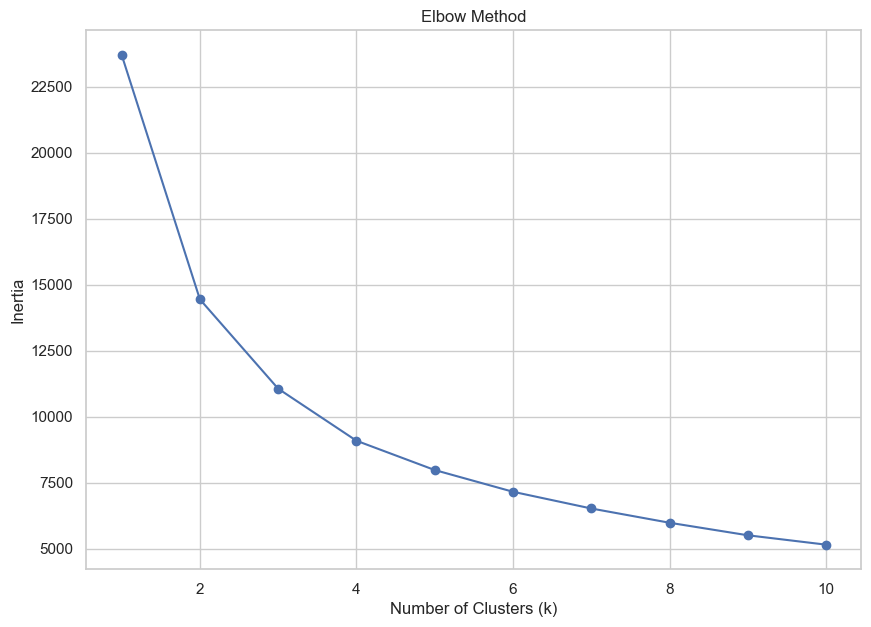

In [4]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 7))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

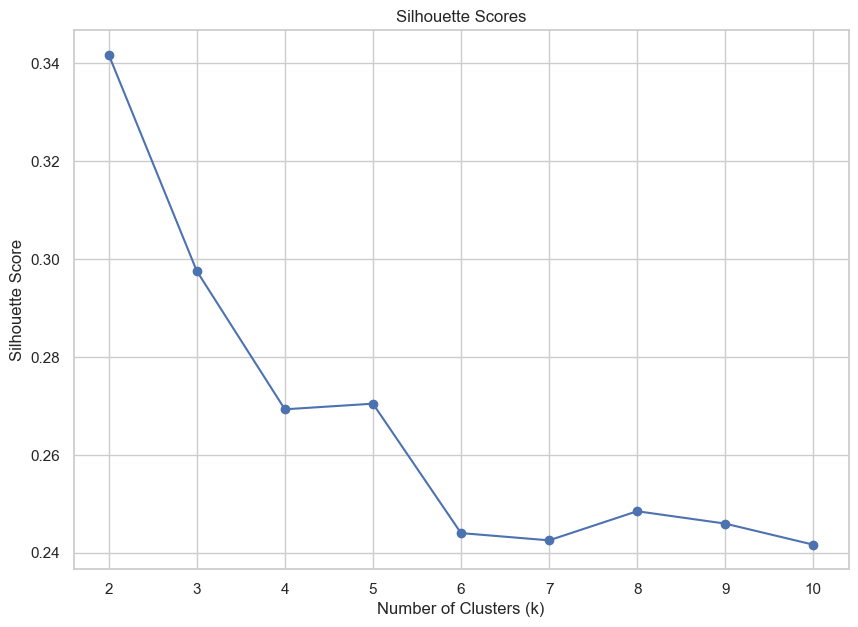

In [5]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 7))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [6]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

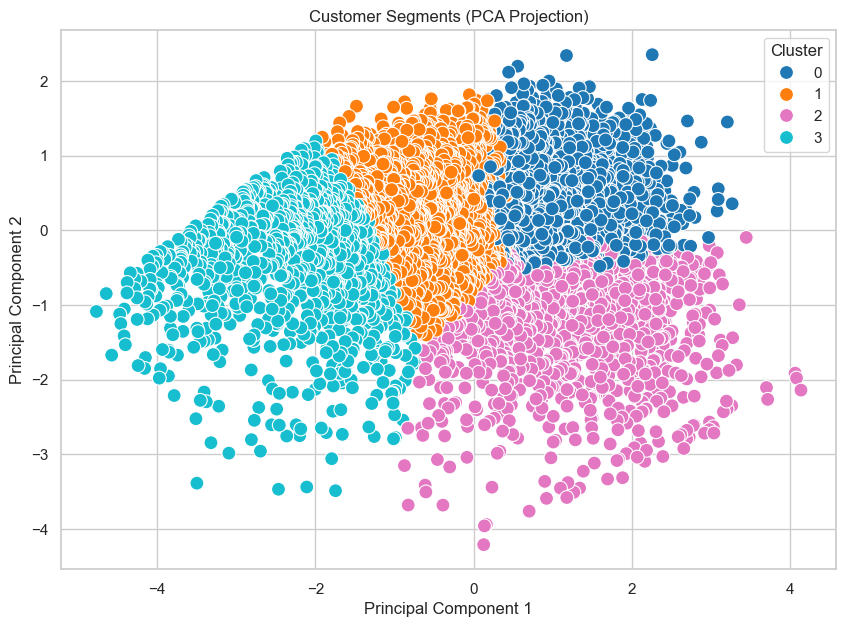

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Custom palette designed for high contrast and colorblind safety (Blue, Orange, Magenta, Teal)
custom_palette = ['#1f77b4', '#ff7f0e', '#e377c2', '#17becf']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette=custom_palette,
    data=df,
    s=100
)
plt.title("Customer Segments (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

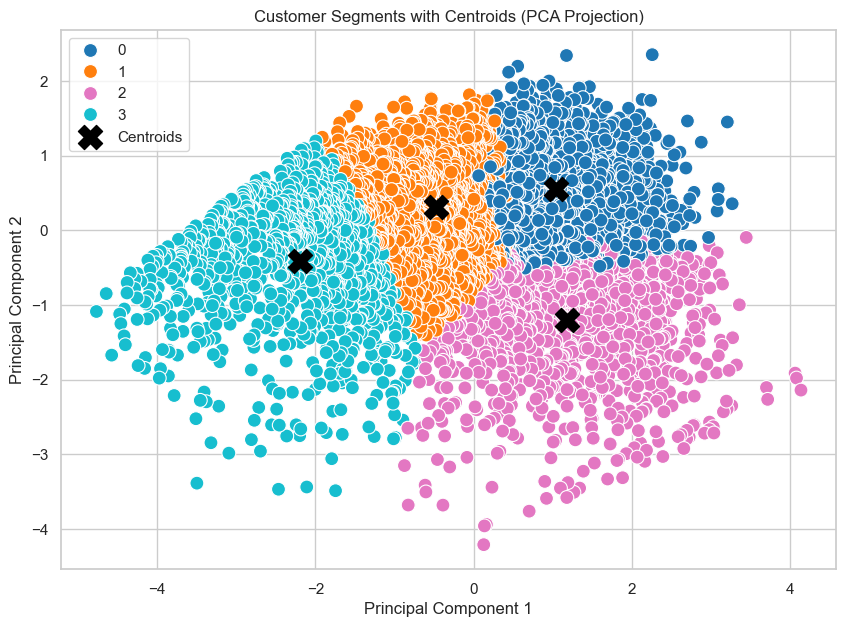

In [8]:
centroids_pca = pca.transform(final_kmeans.cluster_centers_)
custom_palette = ['#1f77b4', '#ff7f0e', '#e377c2', '#17becf']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette=custom_palette,
    data=df,
    s=100
)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)
plt.title("Customer Segments with Centroids (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [9]:
cluster_profile = df.groupby('Cluster')[['recency', 'frequency', 'monetary']].mean().round(2)
cluster_profile['Customer Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,recency,frequency,monetary,Customer Count
Cluster,,,,
0,117.23,6.24,1368.67,2366
1,205.86,3.51,487.77,2867
2,16.29,5.22,786.23,1405
3,283.24,1.85,97.97,1265


In [10]:
segment_names = {
    0: "At-Risk Customers",
    1: "Premium Customers",
    2: "Regular Customers",
    3: "New/Recent Customers"
}

df['Segment'] = df['Cluster'].map(segment_names)
df.to_csv("../dataset/customer_segments_kmeans.csv", index=False)
cluster_profile.to_csv("../dataset/cluster_profile.csv", index=False)